In [3]:
import os
import copy
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuration du matériel (Calcul sur GPU/CUDA si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📊 PyTorch est prêt ! Exécution sur le périphérique : {device}")

📊 PyTorch est prêt ! Exécution sur le périphérique : cpu


In [4]:
# Chemin d'accès relatif (ton notebook est dans /notebooks, il recule donc d'un dossier avec "../")
data_dir = "../data/raw/chest_xray/"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# Transformations PyTorch (Redimensionnement à 128x128 et Normalisation standard)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(), # Augmentation de données contre l'overfitting
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Chargement automatique des classes (NORMAL et PNEUMONIA) via ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(train_dir, transform=data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, transform=data_transforms['val_test']),
    'test': datasets.ImageFolder(test_dir, transform=data_transforms['val_test'])
}

# Création des DataLoaders par lots (Batch size = 32)
train_loader = DataLoader(image_datasets['train'], batch_size=32, shuffle=True)
val_loader = DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
test_loader = DataLoader(image_datasets['test'], batch_size=32, shuffle=False)

print("✅ Images chargées avec succès ! Structure des données :")
print(f" -> Nombre d'images d'entraînement : {len(image_datasets['train'])}")
print(f" -> Nombre d'images de validation  : {len(image_datasets['val'])}")
print(f" -> Nombre d'images de test        : {len(image_datasets['test'])}")

✅ Images chargées avec succès ! Structure des données :
 -> Nombre d'images d'entraînement : 5216
 -> Nombre d'images de validation  : 16
 -> Nombre d'images de test        : 624


In [5]:
# Chemin d'accès relatif (ton notebook est dans /notebooks, il recule donc d'un dossier avec "../")
data_dir = "../data/raw/chest_xray/"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# Transformations PyTorch (Redimensionnement à 128x128 et Normalisation standard)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(), # Augmentation de données contre l'overfitting
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Chargement automatique des classes (NORMAL et PNEUMONIA) via ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(train_dir, transform=data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, transform=data_transforms['val_test']),
    'test': datasets.ImageFolder(test_dir, transform=data_transforms['val_test'])
}

# Création des DataLoaders par lots (Batch size = 32)
train_loader = DataLoader(image_datasets['train'], batch_size=32, shuffle=True)
val_loader = DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
test_loader = DataLoader(image_datasets['test'], batch_size=32, shuffle=False)

print("✅ Images chargées avec succès ! Structure des données :")
print(f" -> Nombre d'images d'entraînement : {len(image_datasets['train'])}")
print(f" -> Nombre d'images de validation  : {len(image_datasets['val'])}")
print(f" -> Nombre d'images de test        : {len(image_datasets['test'])}")

✅ Images chargées avec succès ! Structure des données :
 -> Nombre d'images d'entraînement : 5216
 -> Nombre d'images de validation  : 16
 -> Nombre d'images de test        : 624


In [6]:
class ChestXrayCNN(nn.Module):
    def __init__(self):
        super(ChestXrayCNN, self).__init__()
        
        # Bloc Convolutif 1 : Entrée (3, 128, 128) -> Sortie (16, 64, 64) après Pooling
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Bloc Convolutif 2 : Entrée (16, 64, 64) -> Sortie (32, 32, 32) après Pooling
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Bloc Convolutif 3 : Entrée (32, 32, 32) -> Sortie (64, 16, 16) après Pooling
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Couches de Classification Fully Connected (Totalement connectées)
        # Dimensions aplaties : 64 canaux * 16 de hauteur * 16 de largeur = 16384 caractéristiques
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # Protection contre le surapprentissage
        self.fc2 = nn.Linear(128, 1)   # 1 seule sortie car problème binaire (0 ou 1)
        self.sigmoid = nn.Sigmoid()    # Probabilité finale entre 0 et 1
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        
        # Aplatissement du tenseur (Flatten)
        x = x.view(x.size(0), -1) 
        
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x

# Instanciation du modèle avec les minuscules corrigées
model_cnn = ChestXrayCNN().to(device)

# Définition de la fonction de perte et de l'optimiseur
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

print("🚀 Modèle instancié, paramètres chargés et connectés à l'optimiseur Adam !")

🚀 Modèle instancié, paramètres chargés et connectés à l'optimiseur Adam !


In [7]:
epochs = 10
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_weights = None

print("⏳ Lancement de l'entraînement, veuillez patienter (10 époques)...")
start_time = time.time()

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model_cnn.train()
    running_train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- PHASE DE VALIDATION ---
    model_cnn.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    # Suivi et sauvegarde de la meilleure configuration de poids
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model_cnn.state_dict())
        
    print(f" Époque {epoch+1:2d}/{epochs} -> Loss Train: {epoch_train_loss:.4f} | Loss Val: {epoch_val_loss:.4f}")

# Recharger les meilleurs poids et sauvegarder le fichier final .pth
if best_model_weights is not None:
    model_cnn.load_state_dict(best_model_weights)

# Vérifier et créer le dossier 'models' si manquant avant sauvegarde
os.makedirs("../models", exist_ok=True)
torch.save(model_cnn.state_dict(), "../models/best_cnn_model.pth")

duration = (time.time() - start_time) / 60
print(f"\n💾 Entraînement fini avec succès en {duration:.2f} min ! Modèle enregistré.")

⏳ Lancement de l'entraînement, veuillez patienter (10 époques)...
 Époque  1/10 -> Loss Train: 0.2620 | Loss Val: 0.4145
 Époque  2/10 -> Loss Train: 0.1361 | Loss Val: 0.8049
 Époque  3/10 -> Loss Train: 0.1240 | Loss Val: 0.3990
 Époque  4/10 -> Loss Train: 0.1064 | Loss Val: 0.3839
 Époque  5/10 -> Loss Train: 0.0979 | Loss Val: 0.2543
 Époque  6/10 -> Loss Train: 0.0853 | Loss Val: 0.1726
 Époque  7/10 -> Loss Train: 0.0851 | Loss Val: 0.4720
 Époque  8/10 -> Loss Train: 0.0743 | Loss Val: 0.4039
 Époque  9/10 -> Loss Train: 0.0651 | Loss Val: 0.2559
 Époque 10/10 -> Loss Train: 0.0646 | Loss Val: 0.3241

💾 Entraînement fini avec succès en 30.98 min ! Modèle enregistré.


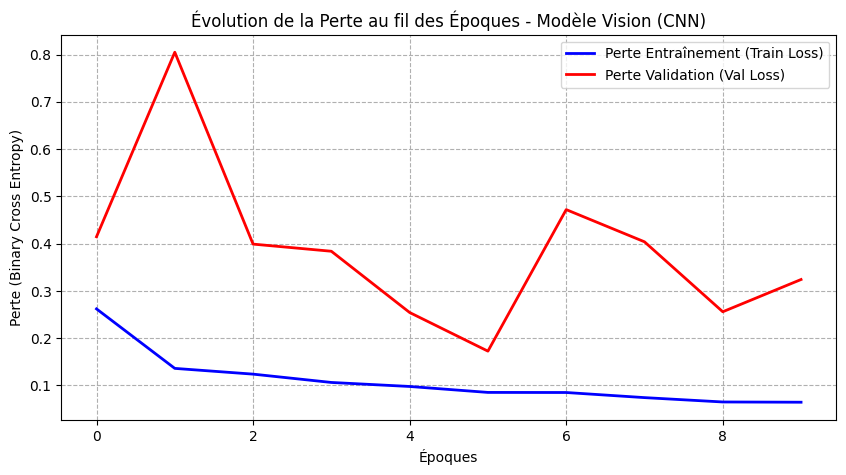

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Perte Entraînement (Train Loss)', color='blue', lw=2)
plt.plot(val_losses, label='Perte Validation (Val Loss)', color='red', lw=2)
plt.xlabel('Époques')
plt.ylabel('Perte (Binary Cross Entropy)')
plt.title("Évolution de la Perte au fil des Époques - Modèle Vision (CNN)")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()


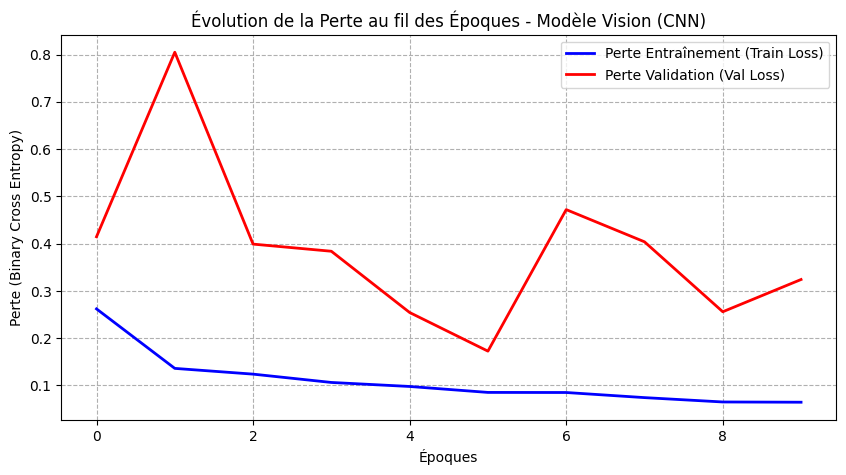

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Perte Entraînement (Train Loss)', color='blue', lw=2)
plt.plot(val_losses, label='Perte Validation (Val Loss)', color='red', lw=2)
plt.xlabel('Époques')
plt.ylabel('Perte (Binary Cross Entropy)')
plt.title("Évolution de la Perte au fil des Époques - Modèle Vision (CNN)")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()